In [89]:
import os
import io
import gzip
import json
import shutil
import requests
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub


In [90]:
# Download latest version
path = kagglehub.dataset_download("ammaraahmad/us-ecommerce-record-2020")

ecom_data = pd.read_csv(os.path.join(path, os.listdir(path)[0]), encoding='latin1')
ecom_data.head()

,Order Date,Row ID,Order ID,Ship Mode,Customer ID,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,01-01-20,849,CA-2017-107503,Standard Class,GA-14725,Consumer,United States,Lorain,Ohio,44052,East,FUR-FU-10003878,Furniture,Furnishings,"Linden 10"" Round Wall Clock, Black",48.896,4,0.2,8.5568
1,01-01-20,4010,CA-2017-144463,Standard Class,SC-20725,Consumer,United States,Los Angeles,California,90036,West,FUR-FU-10001215,Furniture,Furnishings,"Howard Miller 11-1/2"" Diameter Brentwood Wall ...",474.430,11,0.0,199.2606
2,01-01-20,6683,CA-2017-154466,First Class,DP-13390,Home Office,United States,Franklin,Wisconsin,53132,Central,OFF-BI-10002012,Office Supplies,Binders,Wilson Jones Easy Flow II Sheet Lifters,3.600,2,0.0,1.7280
3,01-01-20,8070,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,77340,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,454.560,5,0.2,-107.9580
4,01-01-20,8071,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,77340,Central,FUR-FU-10002116,Furniture,Furnishings,"Tenex Carpeted, Granite-Look or Clear Contempo...",141.420,5,0.6,-187.3815


In [91]:
# ── 1. Basic overview ────────────────────────────────────────────────
print("Shape:", ecom_data.shape)
print("\nDtypes:\n", ecom_data.dtypes)
print("\nMissing values:\n", ecom_data.isnull().sum())
print("\nDuplicates:", ecom_data.duplicated().sum())

Shape: (3312, 19)

Dtypes:
 Order Date       object
Row ID            int64
Order ID         object
Ship Mode        object
Customer ID      object
Segment          object
Country          object
City             object
State            object
Postal Code       int64
Region           object
Product ID       object
Category         object
Sub-Category     object
Product Name     object
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

Missing values:
 Order Date      0
Row ID          0
Order ID        0
Ship Mode       0
Customer ID     0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Product ID      0
Category        0
Sub-Category    0
Product Name    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

Duplicates: 0


In [92]:
# ── 2. Statistical summary ───────────────────────────────────────────
print(ecom_data.describe(include="all"))

       Order Date       Row ID        Order ID       Ship Mode Customer ID  \
count        3312  3312.000000            3312            3312        3312   
unique        322          NaN            1687               4         693   
top      02-09-20          NaN  CA-2017-100111  Standard Class    SV-20365   
freq           36          NaN              14            1897          20   
mean          NaN  5087.107488             NaN             NaN         NaN   
std           NaN  2817.482266             NaN             NaN         NaN   
min           NaN    13.000000             NaN             NaN         NaN   
25%           NaN  2655.750000             NaN             NaN         NaN   
50%           NaN  5183.500000             NaN             NaN         NaN   
75%           NaN  7498.250000             NaN             NaN         NaN   
max           NaN  9994.000000             NaN             NaN         NaN   

         Segment        Country           City       State   Po

In [93]:
# ── 3. Preview unique values for object cols ─────────────────────────
for col in ecom_data.select_dtypes(include=["object"]).columns:
    print(f"\n{col} — {ecom_data[col].nunique()} unique values")
    print(ecom_data[col].value_counts().head(5))


Order Date — 322 unique values
Order Date
02-09-20    36
01-12-20    34
02-12-20    34
09-12-20    33
08-12-20    30
Name: count, dtype: int64

Order ID — 1687 unique values
Order ID
CA-2017-100111    14
CA-2017-157987    12
CA-2017-140949     9
CA-2017-117457     9
CA-2017-118017     8
Name: count, dtype: int64

Ship Mode — 4 unique values
Ship Mode
Standard Class    1897
Second Class       657
First Class        572
Same Day           186
Name: count, dtype: int64

Customer ID — 693 unique values
Customer ID
SV-20365    20
JL-15835    20
MH-18115    19
Dp-13240    19
LC-16870    17
Name: count, dtype: int64

Segment — 3 unique values
Segment
Consumer       1668
Corporate       980
Home Office     664
Name: count, dtype: int64

Country — 1 unique values
Country
United States    3312
Name: count, dtype: int64

City — 350 unique values
City
New York City    306
Los Angeles      210
San Francisco    190
Seattle          182
Philadelphia     182
Name: count, dtype: int64

State — 47 uniq

In [94]:
# ── 4. Fix dtypes ────────────────────────────────────────────────────
# Inspect columns first — adjust these based on what you see above
print(ecom_data.columns.tolist())

['Order Date', 'Row ID', 'Order ID', 'Ship Mode', 'Customer ID', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [95]:
# ── Fix dtypes ───────────────────────────────────────────────────────
# Parse date
ecom_data["Order Date"] = pd.to_datetime(ecom_data["Order Date"], errors="coerce")

# Numerics
num_cols = ["Sales", "Quantity", "Discount", "Profit"]
for col in num_cols:
    ecom_data[col] = pd.to_numeric(ecom_data[col], errors="coerce")

# Categoricals
cat_cols = ["Ship Mode", "Segment", "Country", "City", "State", 
            "Region", "Category", "Sub-Category"]
for col in cat_cols:
    ecom_data[col] = ecom_data[col].astype("category")

# Row ID is just an index — drop it
ecom_data = ecom_data.drop(columns=["Row ID"])

print("Dtypes after fix:\n", ecom_data.dtypes)

Dtypes after fix:
 Order Date      datetime64[ns]
Order ID                object
Ship Mode             category
Customer ID             object
Segment               category
Country               category
City                  category
State                 category
Postal Code              int64
Region                category
Product ID              object
Category              category
Sub-Category          category
Product Name            object
Sales                  float64
Quantity                 int64
Discount               float64
Profit                 float64
dtype: object


C:\Users\peace\AppData\Local\Temp\ipykernel_15424\3092916431.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ecom_data["Order Date"] = pd.to_datetime(ecom_data["Order Date"], errors="coerce")


In [96]:
# ── Extract date parts ───────────────────────────────────────────────
ecom_data["year"]  = ecom_data["Order Date"].dt.year
ecom_data["month"] = ecom_data["Order Date"].dt.month
ecom_data["dow"]   = ecom_data["Order Date"].dt.day_name()

In [97]:
# ── Sanity checks ────────────────────────────────────────────────────
print("Discount range (0–1 expected):", ecom_data["Discount"].min(), "–", ecom_data["Discount"].max())
print("Quantity min (expect ≥1):", ecom_data["Quantity"].min())
print("Nulls:\n", ecom_data.isnull().sum())
print("Duplicates:", ecom_data.duplicated().sum())

Discount range (0–1 expected): 0.0 – 0.8
Quantity min (expect ≥1): 1
Nulls:
 Order Date      0
Order ID        0
Ship Mode       0
Customer ID     0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Product ID      0
Category        0
Sub-Category    0
Product Name    0
Sales           0
Quantity        0
Discount        0
Profit          0
year            0
month           0
dow             0
dtype: int64
Duplicates: 0


In [98]:
# ── Remove bad rows ──────────────────────────────────────────────────
before = len(ecom_data)
ecom_data = ecom_data.dropna(subset=["Order ID", "Customer ID", "Sales"])
ecom_data = ecom_data[ecom_data["Quantity"] >= 1]
ecom_data = ecom_data.drop_duplicates()
print(f"Removed {before - len(ecom_data)} bad rows — {len(ecom_data)} remain")

Removed 0 bad rows — 3312 remain


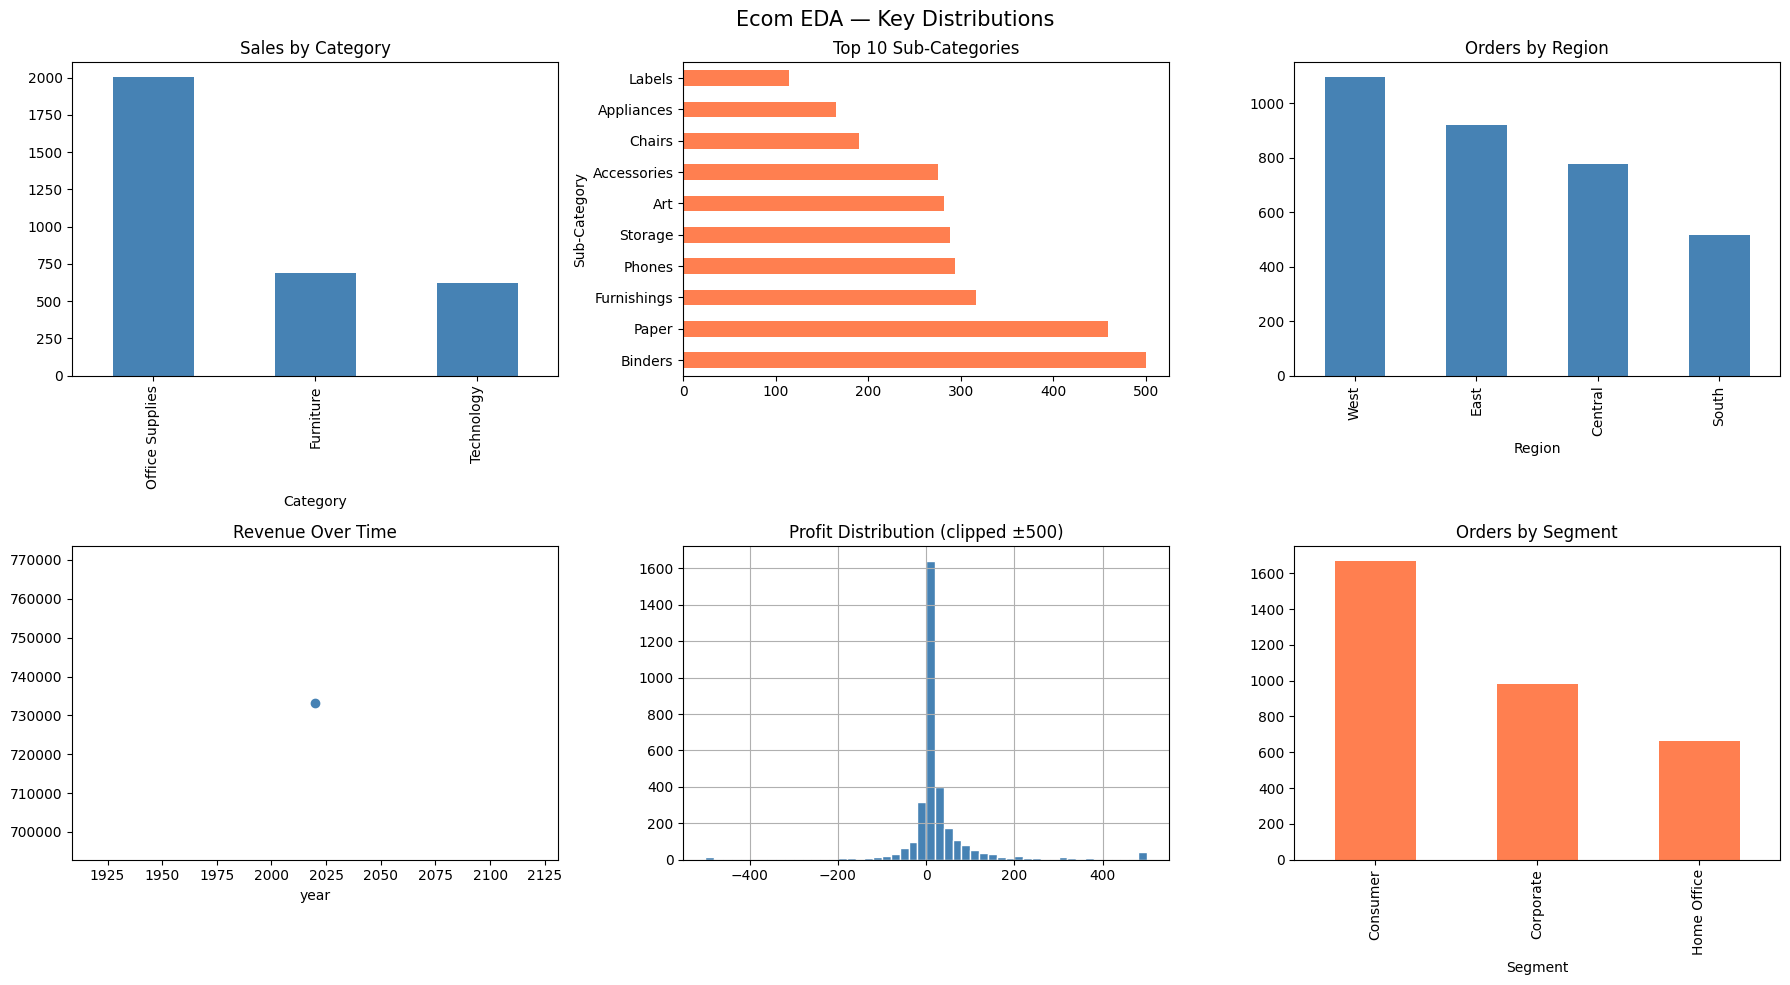

In [99]:
# ── Distributions ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Ecom EDA — Key Distributions", fontsize=15)

ecom_data["Category"].value_counts().plot(
    kind="bar", ax=axes[0,0], title="Sales by Category", color="steelblue")

ecom_data["Sub-Category"].value_counts().head(10).plot(
    kind="barh", ax=axes[0,1], title="Top 10 Sub-Categories", color="coral")

ecom_data["Region"].value_counts().plot(
    kind="bar", ax=axes[0,2], title="Orders by Region", color="steelblue")

ecom_data.groupby("year")["Sales"].sum().plot(
    kind="line", ax=axes[1,0], title="Revenue Over Time", marker="o", color="steelblue")

ecom_data["Profit"].clip(-500, 500).hist(
    bins=50, ax=axes[1,1], color="steelblue", edgecolor="white")
axes[1,1].set_title("Profit Distribution (clipped ±500)")

ecom_data["Segment"].value_counts().plot(
    kind="bar", ax=axes[1,2], title="Orders by Segment", color="coral")

plt.tight_layout()
plt.show()

In [100]:
# ── 9. Final summary ─────────────────────────────────────────────────
print("Final shape:", ecom_data.shape)
print("\nSample rows:")
ecom_data.head(3)

Final shape: (3312, 21)

Sample rows:


,Order Date,Order ID,Ship Mode,Customer ID,Segment,Country,City,State,Postal Code,Region,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,year,month,dow
0,2020-01-01,CA-2017-107503,Standard Class,GA-14725,Consumer,United States,Lorain,Ohio,44052,East,...,Furniture,Furnishings,"Linden 10"" Round Wall Clock, Black",48.896,4,0.2,8.5568,2020,1,Wednesday
1,2020-01-01,CA-2017-144463,Standard Class,SC-20725,Consumer,United States,Los Angeles,California,90036,West,...,Furniture,Furnishings,"Howard Miller 11-1/2"" Diameter Brentwood Wall ...",474.430,11,0.0,199.2606,2020,1,Wednesday
2,2020-01-01,CA-2017-154466,First Class,DP-13390,Home Office,United States,Franklin,Wisconsin,53132,Central,...,Office Supplies,Binders,Wilson Jones Easy Flow II Sheet Lifters,3.600,2,0.0,1.7280,2020,1,Wednesday


In [101]:
# The base URL provided by the lab (raw review categories)
BASE_URL = "https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/review_categories/"

# List of some categories to sample (you can add all 33+ here)
categories = [
    "All_Beauty", "Amazon_Fashion", "Appliances", "Arts_Crafts_and_Sewing",
    "Automotive", "Baby_Products", "Beauty_and_Personal_Care", "Books",
    "CDs_and_Vinyl", "Cell_Phones_and_Accessories", "Clothing_Shoes_and_Jewelry",
    "Digital_Music", "Electronics", "Gift_Cards", "Grocery_and_Gourmet_Food",
    "Handmade_Products", "Health_and_Household", "Health_and_Personal_Care",
    "Home_and_Kitchen", "Industrial_and_Scientific", "Kindle_Store",
    "Magazine_Subscriptions", "Movies_and_TV", "Musical_Instruments",
    "Office_Products", "Patio_Lawn_and_Garden", "Pet_Supplies", "Software",
    "Sports_and_Outdoors", "Subscription_Boxes", "Tools_and_Home_Improvement",
    "Toys_and_Games", "Video_Games", "Unknown"
]

def sample_amazon_dataset(category_list, sample_size=100):
    all_data = []

    for cat in category_list:
        # Construct the direct download URL for the compressed jsonl file
        # Note: The server might require specific headers or a direct file path
        url = f"{BASE_URL}{cat}.jsonl.gz"
        print(f"Streaming sample from {cat}...")

        try:
            # Stream the file from the URL
            response = requests.get(url, stream=True)
            response.raise_for_status()

            # Decompress on the fly
            with gzip.open(response.raw, 'rt', encoding='utf-8') as f:
                cat_sample = []
                for i, line in enumerate(f):
                    cat_sample.append(json.loads(line))
                    if i >= sample_size - 1:
                        break
                
                # Convert this category's sample to a DataFrame
                df_temp = pd.DataFrame(cat_sample)
                df_temp['category_name'] = cat
                all_data.append(df_temp)
                print(f"  Successfully sampled {len(df_temp)} rows.")

        except Exception as e:
            print(f"  Failed to stream {cat}: {e}")

    # Compile all samples into one master DataFrame
    if all_data:
        amazon_review_df = pd.concat(all_data, ignore_index=True)
        return amazon_review_df
    return pd.DataFrame()

# Execute sampling
amazon_review_df = sample_amazon_dataset(categories, sample_size=100000)
print(amazon_review_df.info())

Streaming sample from All_Beauty...
  Successfully sampled 100000 rows.
Streaming sample from Amazon_Fashion...
  Successfully sampled 100000 rows.
Streaming sample from Appliances...
  Successfully sampled 100000 rows.
Streaming sample from Arts_Crafts_and_Sewing...
  Successfully sampled 100000 rows.
Streaming sample from Automotive...
  Successfully sampled 100000 rows.
Streaming sample from Baby_Products...
  Successfully sampled 100000 rows.
Streaming sample from Beauty_and_Personal_Care...
  Successfully sampled 100000 rows.
Streaming sample from Books...
  Successfully sampled 100000 rows.
Streaming sample from CDs_and_Vinyl...
  Successfully sampled 100000 rows.
Streaming sample from Cell_Phones_and_Accessories...
  Successfully sampled 100000 rows.
Streaming sample from Clothing_Shoes_and_Jewelry...
  Successfully sampled 100000 rows.
Streaming sample from Digital_Music...
  Successfully sampled 100000 rows.
Streaming sample from Electronics...
  Successfully sampled 100000 ro

In [103]:
# Find hashable columns only
hashable_cols = [col for col in amazon_review_df.columns 
                 if not amazon_review_df[col].apply(lambda x: isinstance(x, list)).any()]

print("Checking duplicates on:", hashable_cols)
print("Duplicates:", amazon_review_df.duplicated(subset=hashable_cols).sum())
# Drop duplicates on key identity columns only
before = len(amazon_review_df)
amazon_review_df = amazon_review_df.drop_duplicates(subset=["user_id", "asin"])
print(f"Removed {before - len(amazon_review_df)} duplicates — {len(amazon_review_df)} remain")
# Convert images column from list to a count — more useful anyway
amazon_review_df["image_count"] = amazon_review_df["images"].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)
amazon_review_df = amazon_review_df.drop(columns=["images"])

print("images column replaced with image_count ✓")

Checking duplicates on: ['rating', 'title', 'text', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase', 'category_name']
Duplicates: 6087
Removed 6090 duplicates — 3281623 remain


C:\Users\peace\AppData\Local\Temp\ipykernel_15424\1476137370.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  amazon_review_df["image_count"] = amazon_review_df["images"].apply(


images column replaced with image_count ✓


In [104]:
# ── 2. Statistical summary ───────────────────────────────────────────
print(amazon_review_df.describe(include="all"))

              rating       title     text        asin parent_asin  \
count   3.281623e+06     3281623  3281623     3281623     3281623   
unique           NaN     1884841  2979091     1829906     1663624   
top              NaN  Five Stars    Great  B00IX1I3G6  B00IX1I3G6   
freq             NaN      236539     7087       22281       22281   
mean    4.305810e+00         NaN      NaN         NaN         NaN   
std     1.198083e+00         NaN      NaN         NaN         NaN   
min     1.000000e+00         NaN      NaN         NaN         NaN   
25%     4.000000e+00         NaN      NaN         NaN         NaN   
50%     5.000000e+00         NaN      NaN         NaN         NaN   
75%     5.000000e+00         NaN      NaN         NaN         NaN   
max     5.000000e+00         NaN      NaN         NaN         NaN   

                             user_id     timestamp  helpful_vote  \
count                        3281623  3.281623e+06  3.281623e+06   
unique                        63366

In [105]:
# ── 3. Fix dtypes ────────────────────────────────────────────────────
# Convert unix timestamp to datetime
amazon_review_df["timestamp"] = pd.to_datetime(amazon_review_df["timestamp"], unit="ms", errors="coerce")

# Rating should be float — coerce anything odd
amazon_review_df["rating"] = pd.to_numeric(amazon_review_df["rating"], errors="coerce")

# Categoricals
cat_cols = ["category_name", "verified_purchase"]
for col in cat_cols:
    if col in amazon_review_df.columns:
        amazon_review_df[col] = amazon_review_df[col].astype("category")

# helpful_vote may be missing or object
if "helpful_vote" in amazon_review_df.columns:
    amazon_review_df["helpful_vote"] = pd.to_numeric(amazon_review_df["helpful_vote"], errors="coerce").fillna(0).astype(int)

print("Dtypes after fix:\n", amazon_review_df.dtypes)

Dtypes after fix:
 rating                      float64
title                        object
text                         object
asin                         object
parent_asin                  object
user_id                      object
timestamp            datetime64[ns]
helpful_vote                  int64
verified_purchase          category
category_name              category
image_count                   int64
dtype: object


In [106]:
# ── 4. Handle missing values ─────────────────────────────────────────
print("Missing before:\n", amazon_review_df.isnull().sum())

# Drop rows with no rating or no user/product ID — unusable for analysis
critical_cols = ["rating", "user_id", "asin"]
before = len(amazon_review_df)
amazon_review_df = amazon_review_df.dropna(subset=critical_cols)
print(f"Dropped {before - len(amazon_review_df)} rows missing critical fields")

# Fill missing text fields
amazon_review_df["title"]      = amazon_review_df["title"].fillna("No Title")
amazon_review_df["text"]       = amazon_review_df["text"].fillna("")
amazon_review_df["verified_purchase"] = amazon_review_df["verified_purchase"].fillna(False)

print("\nMissing after:\n", amazon_review_df.isnull().sum())

Missing before:
 rating               0
title                0
text                 0
asin                 0
parent_asin          0
user_id              0
timestamp            0
helpful_vote         0
verified_purchase    0
category_name        0
image_count          0
dtype: int64
Dropped 0 rows missing critical fields

Missing after:
 rating               0
title                0
text                 0
asin                 0
parent_asin          0
user_id              0
timestamp            0
helpful_vote         0
verified_purchase    0
category_name        0
image_count          0
dtype: int64


In [107]:
# ── 5. Remove bad rows ───────────────────────────────────────────────
before = len(amazon_review_df)

# Rating must be between 1–5
amazon_review_df = amazon_review_df[amazon_review_df["rating"].between(1, 5)]

# Drop exact duplicates
amazon_review_df = amazon_review_df.drop_duplicates()

# Drop duplicate reviews — same user reviewing same product twice
amazon_review_df = amazon_review_df.drop_duplicates(subset=["user_id", "asin"])

print(f"Removed {before - len(amazon_review_df)} bad/duplicate rows — {len(amazon_review_df)} remain")

Removed 0 bad/duplicate rows — 3281623 remain


In [108]:
# ── 6. Feature engineering ───────────────────────────────────────────
# Date parts
amazon_review_df["year"]  = amazon_review_df["timestamp"].dt.year
amazon_review_df["month"] = amazon_review_df["timestamp"].dt.month
amazon_review_df["dow"]   = amazon_review_df["timestamp"].dt.day_name()

# Review text length
amazon_review_df["review_length"] = amazon_review_df["text"].str.len()

# Sentiment bucket from rating
amazon_review_df["sentiment"] = pd.cut(
    amazon_review_df["rating"],
    bins=[0, 2, 3, 5],
    labels=["negative", "neutral", "positive"]
)

print(amazon_review_df[["year","month","dow","review_length","sentiment"]].head())

   year  month        dow  review_length sentiment
0  2020      5    Tuesday            300  positive
1  2020      5     Monday            235  positive
2  2020      5   Saturday             25  positive
3  2022      1     Friday             14  negative
4  2020     12  Wednesday              7  positive


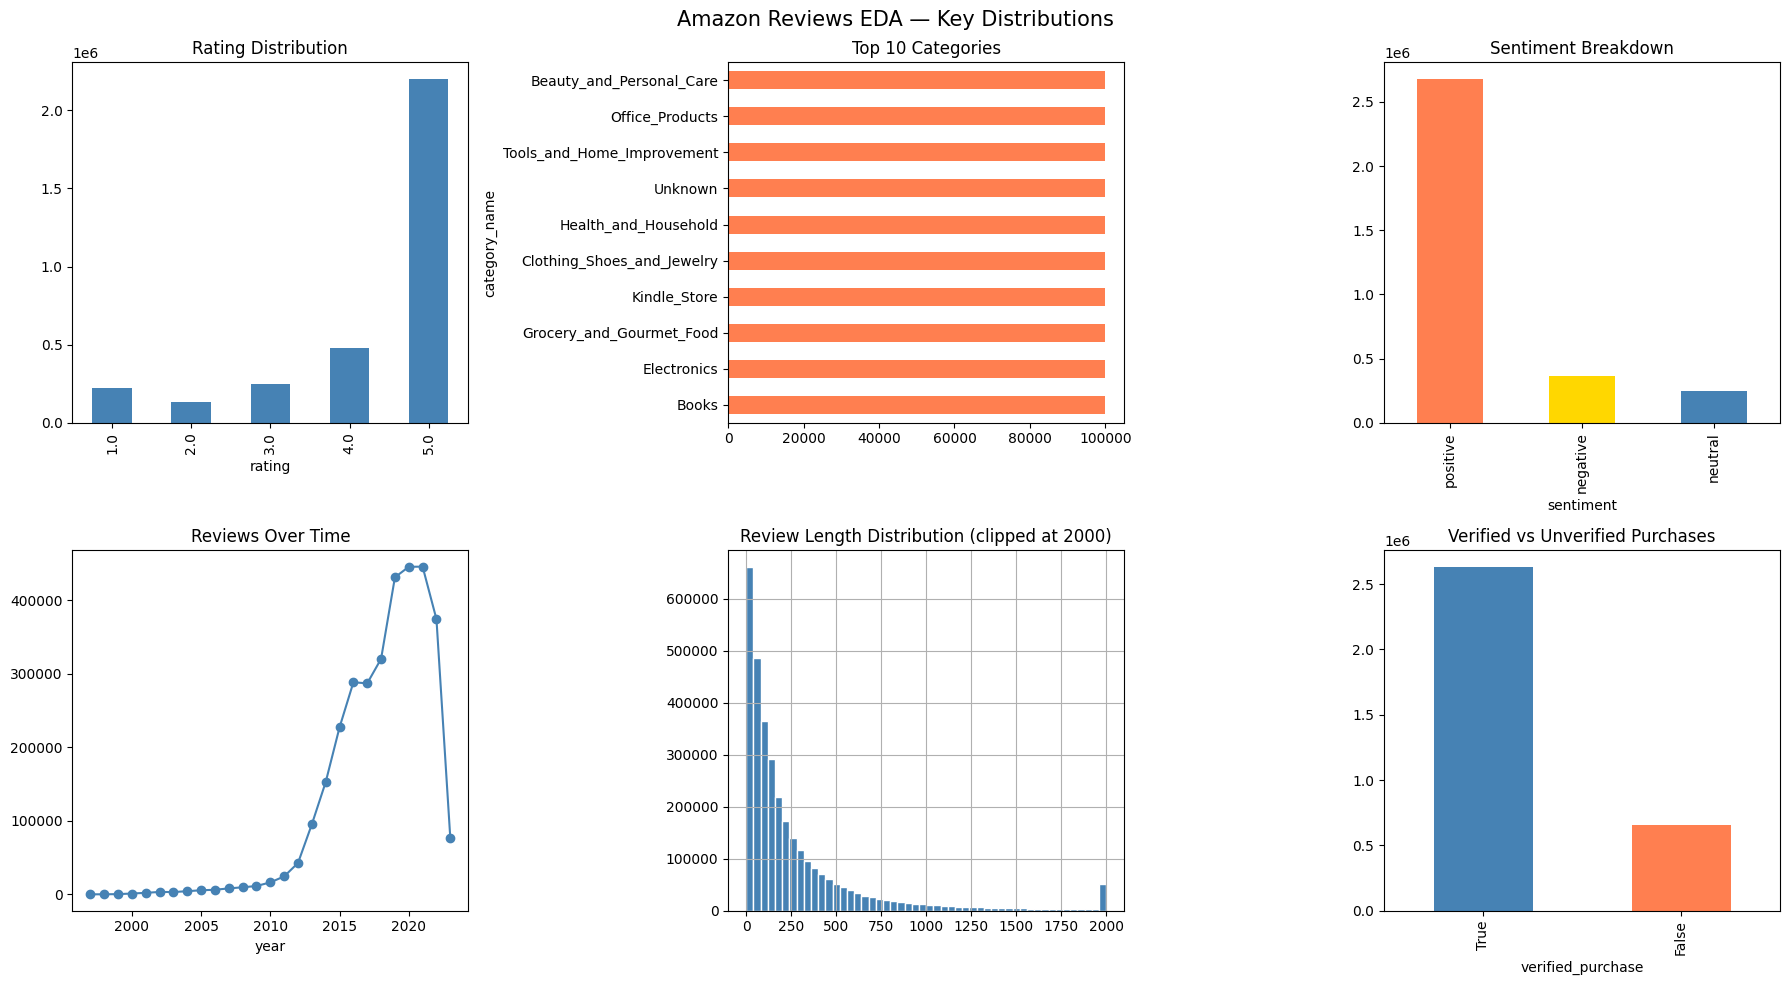

In [110]:
# ── 7. Distribution snapshots ────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Amazon Reviews EDA — Key Distributions", fontsize=15)

# Rating distribution
amazon_review_df["rating"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0,0], title="Rating Distribution", color="steelblue")

# Reviews by category
amazon_review_df["category_name"].value_counts().head(10).plot(
    kind="barh", ax=axes[0,1], title="Top 10 Categories", color="coral")

# Sentiment breakdown
amazon_review_df["sentiment"].value_counts().plot(
    kind="bar", ax=axes[0,2], title="Sentiment Breakdown", color=["coral","gold","steelblue"])

# Reviews over time
amazon_review_df.groupby("year").size().plot(
    kind="line", ax=axes[1,0], title="Reviews Over Time", marker="o", color="steelblue")

# Review length distribution
amazon_review_df["review_length"].clip(upper=2000).hist(
    bins=50, ax=axes[1,1], color="steelblue", edgecolor="white")
axes[1,1].set_title("Review Length Distribution (clipped at 2000)")

# Verified vs unverified
amazon_review_df["verified_purchase"].value_counts().plot(
    kind="bar", ax=axes[1,2], title="Verified vs Unverified Purchases", color=["steelblue","coral"])

plt.tight_layout()
plt.show()

In [111]:
# ── 8. Final summary ─────────────────────────────────────────────────
print("Final shape:", amazon_review_df.shape)
print("\nSentiment breakdown:\n", amazon_review_df["sentiment"].value_counts())
print("\nRating breakdown:\n", amazon_review_df["rating"].value_counts().sort_index())
print("\nDate range:", amazon_review_df["timestamp"].min(), "→", amazon_review_df["timestamp"].max())
print("\nSample rows:")
amazon_review_df.head(3)

Final shape: (3281623, 16)

Sentiment breakdown:
 sentiment
positive    2674822
negative     361722
neutral      245079
Name: count, dtype: int64

Rating breakdown:
 rating
1.0     225550
2.0     136172
3.0     245079
4.0     477195
5.0    2197627
Name: count, dtype: int64

Date range: 1997-08-14 15:11:09 → 2023-08-30 23:13:26.732000

Sample rows:


,rating,title,text,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,category_name,image_count,year,month,dow,review_length,sentiment
0,5.0,Such a lovely scent but not overpowering.,This spray is really nice. It smells really go...,B00YQ6X8EO,B00YQ6X8EO,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2020-05-05 14:08:48.923,0,True,All_Beauty,0,2020,5,Tuesday,300,positive
1,4.0,Works great but smells a little weird.,"This product does what I need it to do, I just...",B081TJ8YS3,B081TJ8YS3,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2020-05-04 18:10:55.070,1,True,All_Beauty,0,2020,5,Monday,235,positive
2,5.0,Yes!,"Smells good, feels great!",B07PNNCSP9,B097R46CSY,AE74DYR3QUGVPZJ3P7RFWBGIX7XQ,2020-05-16 21:41:06.052,2,True,All_Beauty,0,2020,5,Saturday,25,positive


In [112]:
# Clear the cached dataset
cache_path = os.path.expanduser("~/.cache/kagglehub/datasets/psparks/instacart-market-basket-analysis")
if os.path.exists(cache_path):
    shutil.rmtree(cache_path)
    print("Cache cleared")

# Fresh download, then read everything with pandas directly
dataset_path = kagglehub.dataset_download("psparks/instacart-market-basket-analysis")

aisles_df               = pd.read_csv(f"{dataset_path}/aisles.csv")
departments_df          = pd.read_csv(f"{dataset_path}/departments.csv")
order_products_prior_df = pd.read_csv(f"{dataset_path}/order_products__prior.csv", encoding="ISO-8859-1")
order_products_train_df = pd.read_csv(f"{dataset_path}/order_products__train.csv")
products_df             = pd.read_csv(f"{dataset_path}/products.csv")
order_df                = pd.read_csv(f"{dataset_path}/orders.csv")

print("All files loaded successfully")

Cache cleared


100%|██████████| 197M/197M [00:05<00:00, 36.5MB/s] 

Extracting files...


All files loaded successfully


In [113]:
# Merge all dataframes into one
insta_df = (
    order_products_prior_df
    .merge(order_df, on="order_id")
    .merge(products_df, on="product_id")
    .merge(aisles_df, on="aisle_id")
    .merge(departments_df, on="department_id")
)

print(insta_df.shape)
print(insta_df.head())

(32434489, 15)
   order_id  product_id  add_to_cart_order  reordered  user_id eval_set  \
0         2       33120                  1          1   202279    prior   
1         2       28985                  2          1   202279    prior   
2         2        9327                  3          0   202279    prior   
3         2       45918                  4          1   202279    prior   
4         2       30035                  5          0   202279    prior   

   order_number  order_dow  order_hour_of_day  days_since_prior_order  \
0             3          5                  9                     8.0   
1             3          5                  9                     8.0   
2             3          5                  9                     8.0   
3             3          5                  9                     8.0   
4             3          5                  9                     8.0   

            product_name  aisle_id  department_id               aisle  \
0     Organic Egg Whit

In [114]:
insta_df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32434489 entries, 0 to 32434488
Data columns (total 15 columns):
 #   Column                  Non-Null Count     Dtype  
---  ------                  --------------     -----  
 0   order_id                32434489 non-null  int64  
 1   product_id              32434489 non-null  int64  
 2   add_to_cart_order       32434489 non-null  int64  
 3   reordered               32434489 non-null  int64  
 4   user_id                 32434489 non-null  int64  
 5   eval_set                32434489 non-null  object 
 6   order_number            32434489 non-null  int64  
 7   order_dow               32434489 non-null  int64  
 8   order_hour_of_day       32434489 non-null  int64  
 9   days_since_prior_order  30356421 non-null  float64
 10  product_name            32434489 non-null  object 
 11  aisle_id                32434489 non-null  int64  
 12  department_id           32434489 non-null  int64  
 13  aisle                   32434489 non-nul

In [115]:
# ── 1. Basic overview ────────────────────────────────────────────────
print("Shape:", insta_df.shape)
print("\nDtypes:\n", insta_df.dtypes)
print("\nMissing values:\n", insta_df.isnull().sum())
print("\nDuplicates:", insta_df.duplicated().sum())

Shape: (32434489, 15)

Dtypes:
 order_id                    int64
product_id                  int64
add_to_cart_order           int64
reordered                   int64
user_id                     int64
eval_set                   object
order_number                int64
order_dow                   int64
order_hour_of_day           int64
days_since_prior_order    float64
product_name               object
aisle_id                    int64
department_id               int64
aisle                      object
department                 object
dtype: object

Missing values:
 order_id                        0
product_id                      0
add_to_cart_order               0
reordered                       0
user_id                         0
eval_set                        0
order_number                    0
order_dow                       0
order_hour_of_day               0
days_since_prior_order    2078068
product_name                    0
aisle_id                        0
department_id     

In [116]:
# ── 2. Statistical summary ───────────────────────────────────────────
print(insta_df.describe(include="all"))

            order_id    product_id  add_to_cart_order     reordered  \
count   3.243449e+07  3.243449e+07       3.243449e+07  3.243449e+07   
unique           NaN           NaN                NaN           NaN   
top              NaN           NaN                NaN           NaN   
freq             NaN           NaN                NaN           NaN   
mean    1.710749e+06  2.557634e+04       8.351076e+00  5.896975e-01   
std     9.873007e+05  1.409669e+04       7.126671e+00  4.918886e-01   
min     2.000000e+00  1.000000e+00       1.000000e+00  0.000000e+00   
25%     8.559430e+05  1.353000e+04       3.000000e+00  0.000000e+00   
50%     1.711048e+06  2.525600e+04       6.000000e+00  1.000000e+00   
75%     2.565514e+06  3.793500e+04       1.100000e+01  1.000000e+00   
max     3.421083e+06  4.968800e+04       1.450000e+02  1.000000e+00   

             user_id  eval_set  order_number     order_dow  order_hour_of_day  \
count   3.243449e+07  32434489  3.243449e+07  3.243449e+07       3

In [117]:
# ── 3. Fix dtypes ────────────────────────────────────────────────────
# Categoricals — saves memory significantly on large df
cat_cols = ["aisle", "department", "product_name", "eval_set"]
for col in cat_cols:
    if col in insta_df.columns:
        insta_df[col] = insta_df[col].astype("category")

# days_since_prior_order is float due to NaN on first orders — expected, leave as float
print("Dtypes after fix:\n", insta_df.dtypes)

Dtypes after fix:
 order_id                     int64
product_id                   int64
add_to_cart_order            int64
reordered                    int64
user_id                      int64
eval_set                  category
order_number                 int64
order_dow                    int64
order_hour_of_day            int64
days_since_prior_order     float64
product_name              category
aisle_id                     int64
department_id                int64
aisle                     category
department                category
dtype: object


In [118]:
# ── 4. Handle missing values ─────────────────────────────────────────
# days_since_prior_order is NaN for a user's very first order — this is expected
# Fill with 0 to indicate "no prior order"
insta_df["days_since_prior_order"] = insta_df["days_since_prior_order"].fillna(0)

print("Missing after fix:\n", insta_df.isnull().sum())

Missing after fix:
 order_id                  0
product_id                0
add_to_cart_order         0
reordered                 0
user_id                   0
eval_set                  0
order_number              0
order_dow                 0
order_hour_of_day         0
days_since_prior_order    0
product_name              0
aisle_id                  0
department_id             0
aisle                     0
department                0
dtype: int64


In [119]:
# ── 5. Drop duplicates ───────────────────────────────────────────────
before = len(insta_df)
insta_df = insta_df.drop_duplicates()
print(f"Dropped {before - len(insta_df)} duplicate rows — {len(insta_df)} remain")

Dropped 0 duplicate rows — 32434489 remain


In [120]:
# ── 6. Sanity checks on key columns ──────────────────────────────────
print("order_dow range (0–6):",       insta_df["order_dow"].min(), "–", insta_df["order_dow"].max())
print("order_hour_of_day range (0–23):", insta_df["order_hour_of_day"].min(), "–", insta_df["order_hour_of_day"].max())
print("add_to_cart_order min (expect ≥1):", insta_df["add_to_cart_order"].min())
print("reordered values:", insta_df["reordered"].unique())

# Flag any out-of-range values
assert insta_df["order_dow"].between(0, 6).all(),           "order_dow out of range!"
assert insta_df["order_hour_of_day"].between(0, 23).all(),  "order_hour out of range!"
assert insta_df["reordered"].isin([0, 1]).all(),            "reordered has unexpected values!"
print("All sanity checks passed ✓")

order_dow range (0–6): 0 – 6
order_hour_of_day range (0–23): 0 – 23
add_to_cart_order min (expect ≥1): 1
reordered values: [1 0]
All sanity checks passed ✓


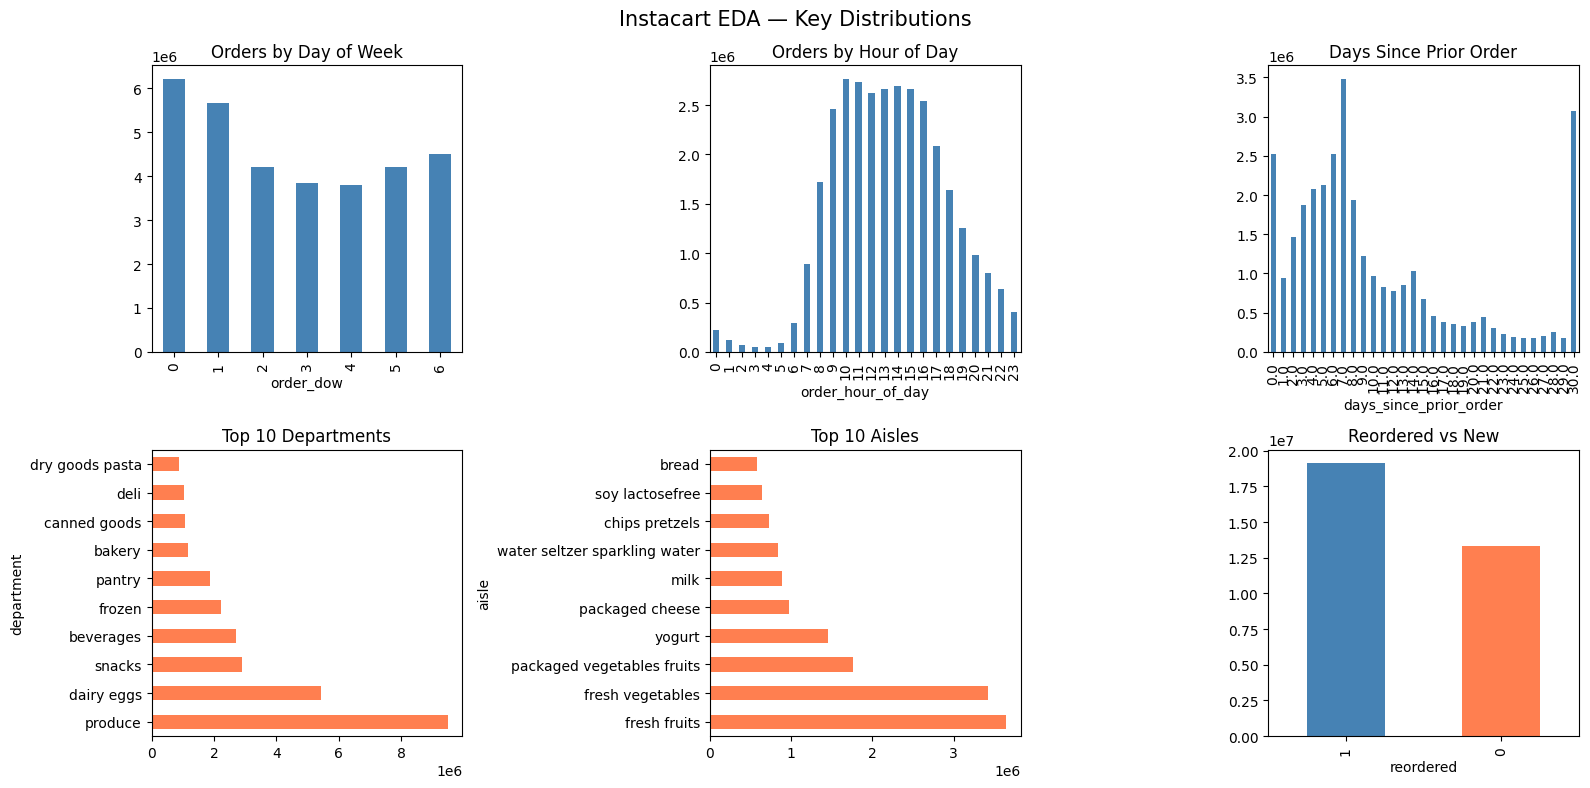

In [121]:
# ── 7. Distribution snapshots ────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Instacart EDA — Key Distributions", fontsize=15)

insta_df["order_dow"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0,0], title="Orders by Day of Week", color="steelblue")

insta_df["order_hour_of_day"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0,1], title="Orders by Hour of Day", color="steelblue")

insta_df["days_since_prior_order"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0,2], title="Days Since Prior Order", color="steelblue")

insta_df["department"].value_counts().head(10).plot(
    kind="barh", ax=axes[1,0], title="Top 10 Departments", color="coral")

insta_df["aisle"].value_counts().head(10).plot(
    kind="barh", ax=axes[1,1], title="Top 10 Aisles", color="coral")

insta_df["reordered"].value_counts().plot(
    kind="bar", ax=axes[1,2], title="Reordered vs New", color=["steelblue","coral"])

plt.tight_layout()
plt.show()

In [122]:
# ── 8. Final clean df summary ─────────────────────────────────────────
print("Final shape:", insta_df.shape)
print("\nSample rows:")
insta_df.head(3)

Final shape: (32434489, 15)

Sample rows:


,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,202279,prior,3,5,9,8.0,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1,202279,prior,3,5,9,8.0,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0,202279,prior,3,5,9,8.0,Garlic Powder,104,13,spices seasonings,pantry


In [123]:
ecom_df_clean = ecom_data.copy()
amazon_review_df_clean = amazon_review_df.copy()
insta_df_clean = insta_df.copy()

#### Multivariate Analysis ###

### 2A — Ecom: Correlation Heatmap + Regional Profitability

C:\Users\peace\AppData\Local\Temp\ipykernel_15424\3659780544.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for cat, grp in ecom_df_clean.groupby("Category"):


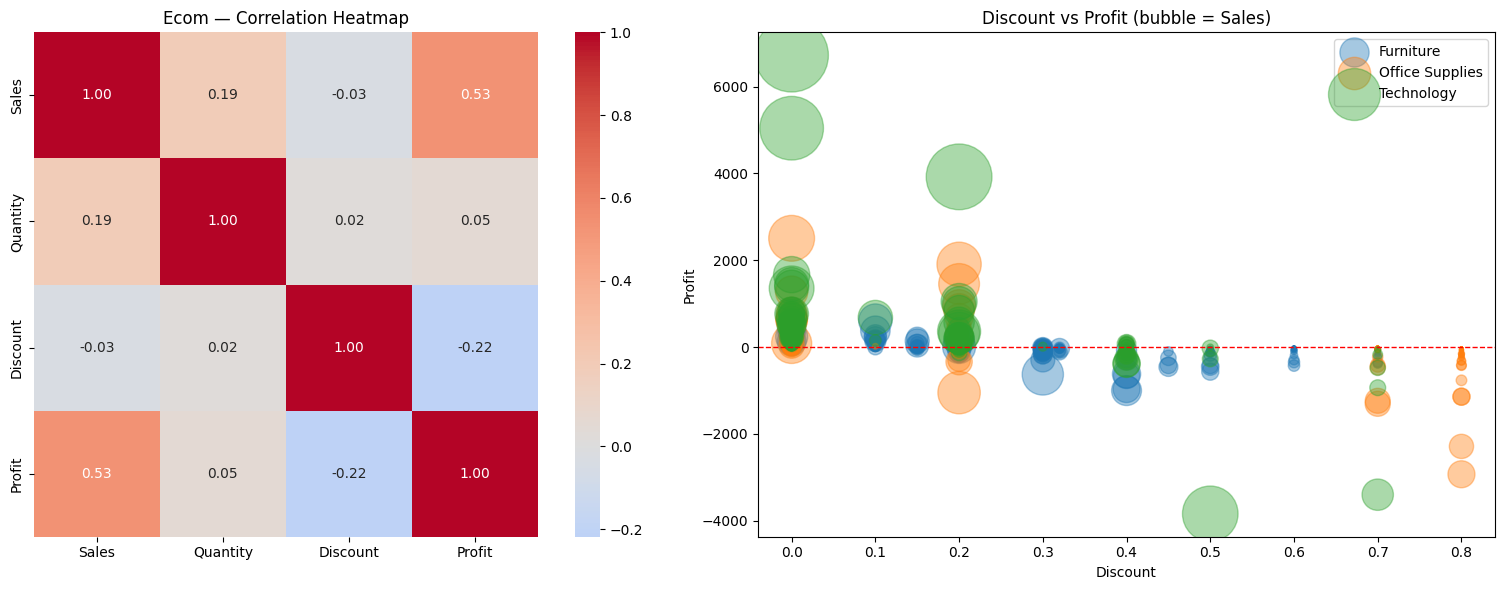

In [124]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ── Correlation heatmap ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

num_cols = ["Sales", "Quantity", "Discount", "Profit"]
corr = ecom_df_clean[num_cols].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=axes[0], square=True)
axes[0].set_title("Ecom — Correlation Heatmap")

# ── Discount vs Profit by Category (bubble = Sales volume) ───────────
for cat, grp in ecom_df_clean.groupby("Category"):
    axes[1].scatter(
        grp["Discount"], grp["Profit"],
        s=grp["Sales"] / 5, alpha=0.4, label=cat
    )
axes[1].axhline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_xlabel("Discount")
axes[1].set_ylabel("Profit")
axes[1].set_title("Discount vs Profit (bubble = Sales)")
axes[1].legend()

plt.tight_layout()
plt.show()

C:\Users\peace\AppData\Local\Temp\ipykernel_15424\3130013539.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  region_stats = ecom_df_clean.groupby("Region")[["Sales","Profit","Discount"]].mean().round(2)
C:\Users\peace\AppData\Local\Temp\ipykernel_15424\3130013539.py:10: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = ecom_df_clean.pivot_table(


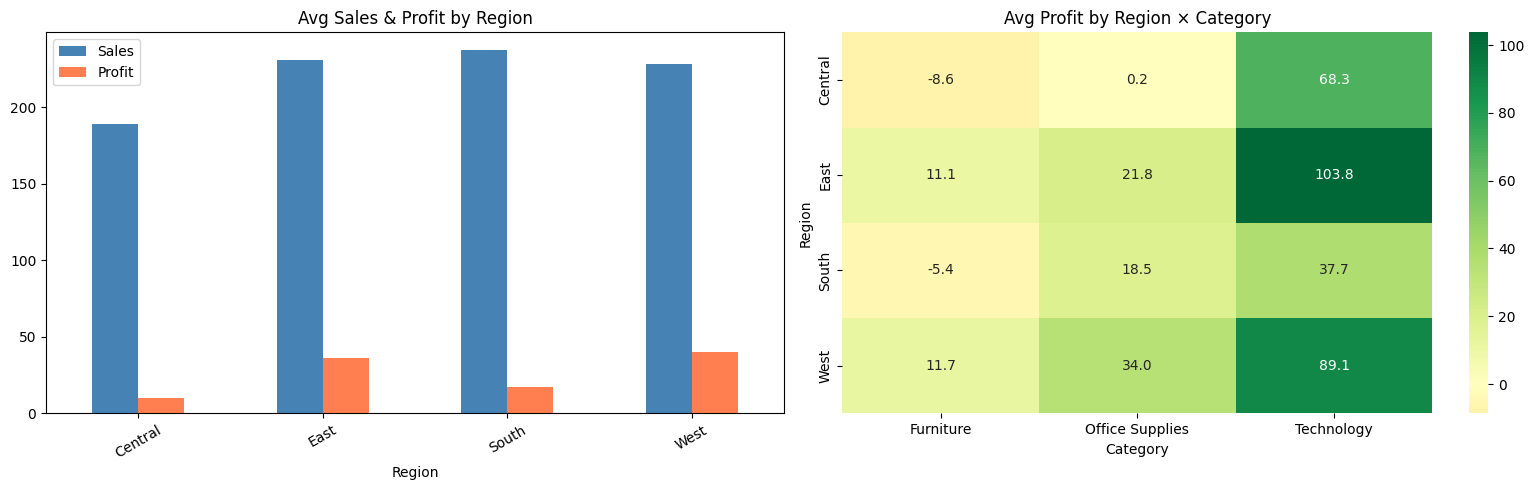

          Sales  Profit  Discount
Region                           
Central  189.07    9.71      0.24
East     231.36   36.08      0.15
South    237.27   17.08      0.16
West     228.43   40.01      0.11


In [125]:
# ── Regional profitability breakdown ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

region_stats = ecom_df_clean.groupby("Region")[["Sales","Profit","Discount"]].mean().round(2)
region_stats[["Sales","Profit"]].plot(kind="bar", ax=axes[0], color=["steelblue","coral"])
axes[0].set_title("Avg Sales & Profit by Region")
axes[0].tick_params(axis='x', rotation=30)

# Profit margin by Category x Region
pivot = ecom_df_clean.pivot_table(
    values="Profit", index="Region", columns="Category", aggfunc="mean"
)
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn", center=0, ax=axes[1])
axes[1].set_title("Avg Profit by Region × Category")

plt.tight_layout()
plt.show()

print(region_stats)

### 2B — Amazon Reviews: Sentiment × Category × Helpfulness

C:\Users\peace\AppData\Local\Temp\ipykernel_15424\1131675305.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("category_name")[["rating","helpful_vote","review_length"]]
C:\Users\peace\AppData\Local\Temp\ipykernel_15424\1131675305.py:16: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot2 = amazon_review_df_clean.pivot_table(


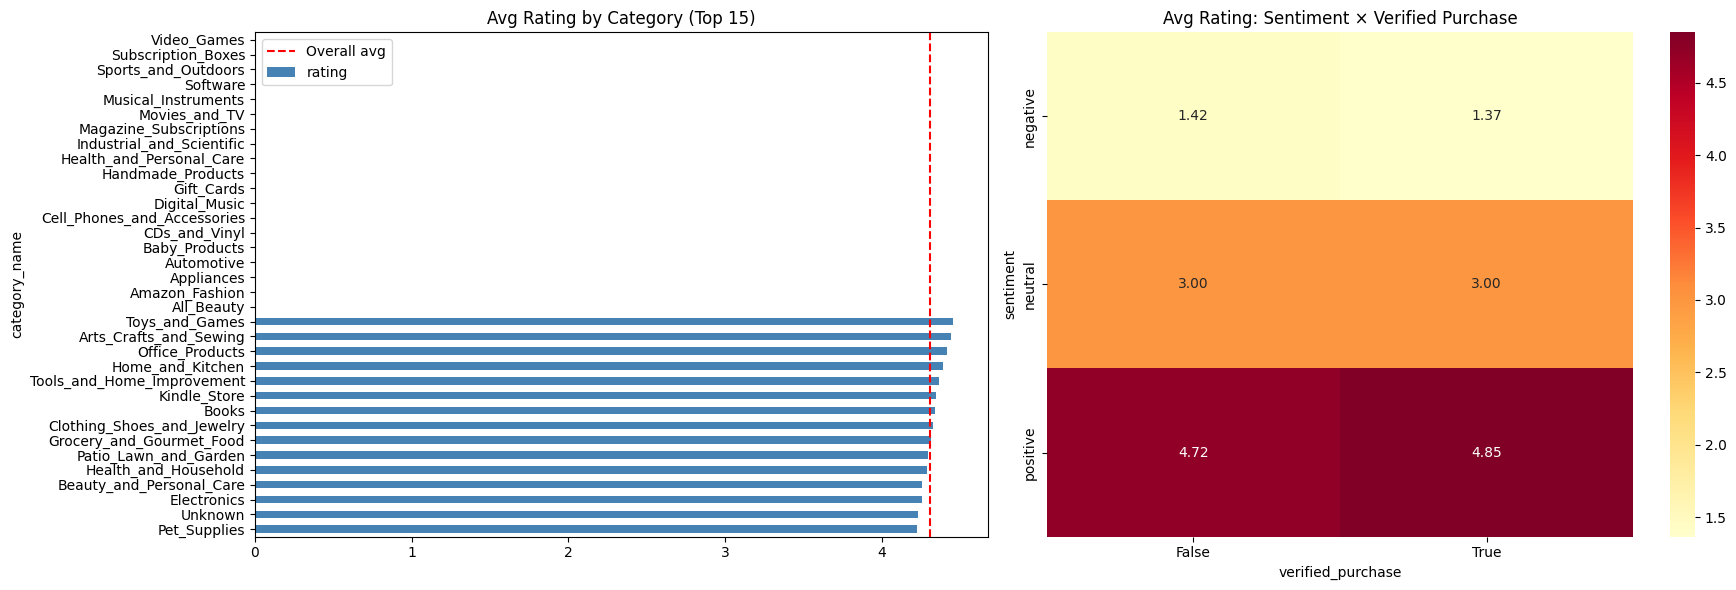

In [126]:
# ── Avg rating by category (top 15) ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

top_cats = amazon_review_df_clean["category_name"].value_counts().head(15).index
cat_stats = (amazon_review_df_clean[amazon_review_df_clean["category_name"].isin(top_cats)]
             .groupby("category_name")[["rating","helpful_vote","review_length"]]
             .mean().sort_values("rating"))

cat_stats["rating"].plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].axvline(amazon_review_df_clean["rating"].mean(), color="red",
                linestyle="--", label="Overall avg")
axes[0].set_title("Avg Rating by Category (Top 15)")
axes[0].legend()

# ── Heatmap: avg rating by sentiment × verified_purchase ─────────────
pivot2 = amazon_review_df_clean.pivot_table(
    values="rating",
    index="sentiment",
    columns="verified_purchase",
    aggfunc="mean"
)
sns.heatmap(pivot2, annot=True, fmt=".2f", cmap="YlOrRd", ax=axes[1])
axes[1].set_title("Avg Rating: Sentiment × Verified Purchase")

plt.tight_layout()
plt.show()

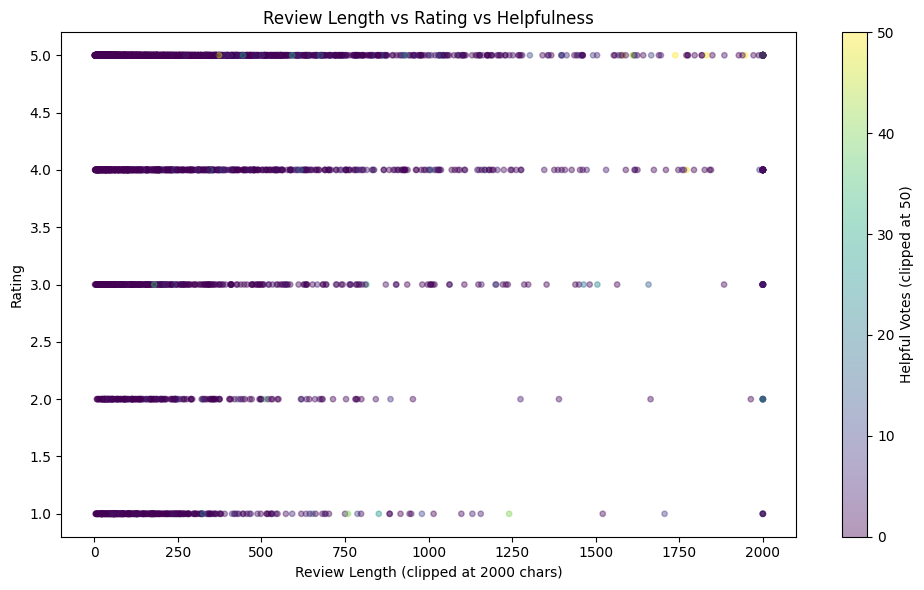

In [127]:
# ── Review length vs rating vs helpfulness (multivariate) ─────────────
fig, ax = plt.subplots(figsize=(10, 6))

sample = amazon_review_df_clean.sample(min(5000, len(amazon_review_df_clean)), random_state=42)
scatter = ax.scatter(
    sample["review_length"].clip(upper=2000),
    sample["rating"],
    c=sample["helpful_vote"].clip(upper=50),
    cmap="viridis", alpha=0.4, s=15
)
plt.colorbar(scatter, ax=ax, label="Helpful Votes (clipped at 50)")
ax.set_xlabel("Review Length (clipped at 2000 chars)")
ax.set_ylabel("Rating")
ax.set_title("Review Length vs Rating vs Helpfulness")
plt.tight_layout()
plt.show()

C:\Users\peace\AppData\Local\Temp\ipykernel_15424\4125592477.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["year_month", "sentiment"])


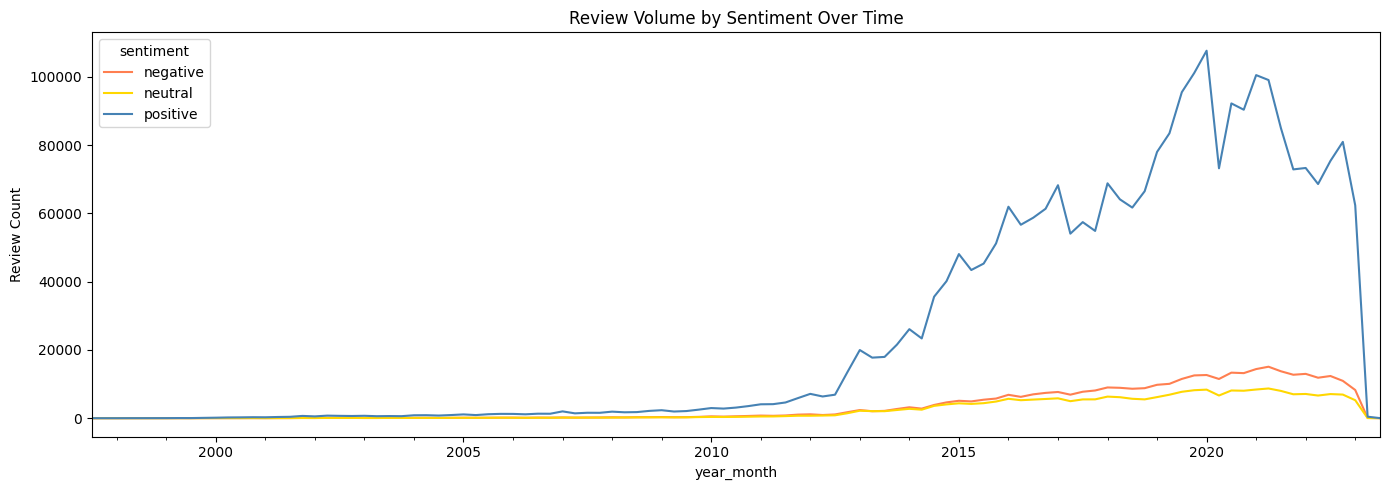

In [128]:
# ── Reviews over time by sentiment ───────────────────────────────────
amazon_review_df_clean["year_month"] = amazon_review_df_clean["timestamp"].dt.to_period("Q")

time_sentiment = (amazon_review_df_clean
                  .groupby(["year_month", "sentiment"])
                  .size()
                  .unstack(fill_value=0))

time_sentiment.plot(figsize=(14, 5), title="Review Volume by Sentiment Over Time",
                    color=["coral", "gold", "steelblue"])
plt.ylabel("Review Count")
plt.tight_layout()
plt.show()

### 2C — Instacart: Basket Behavior × Department × Reorder Patterns

C:\Users\peace\AppData\Local\Temp\ipykernel_15424\704317719.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dept_stats = (insta_df_clean.groupby("department")


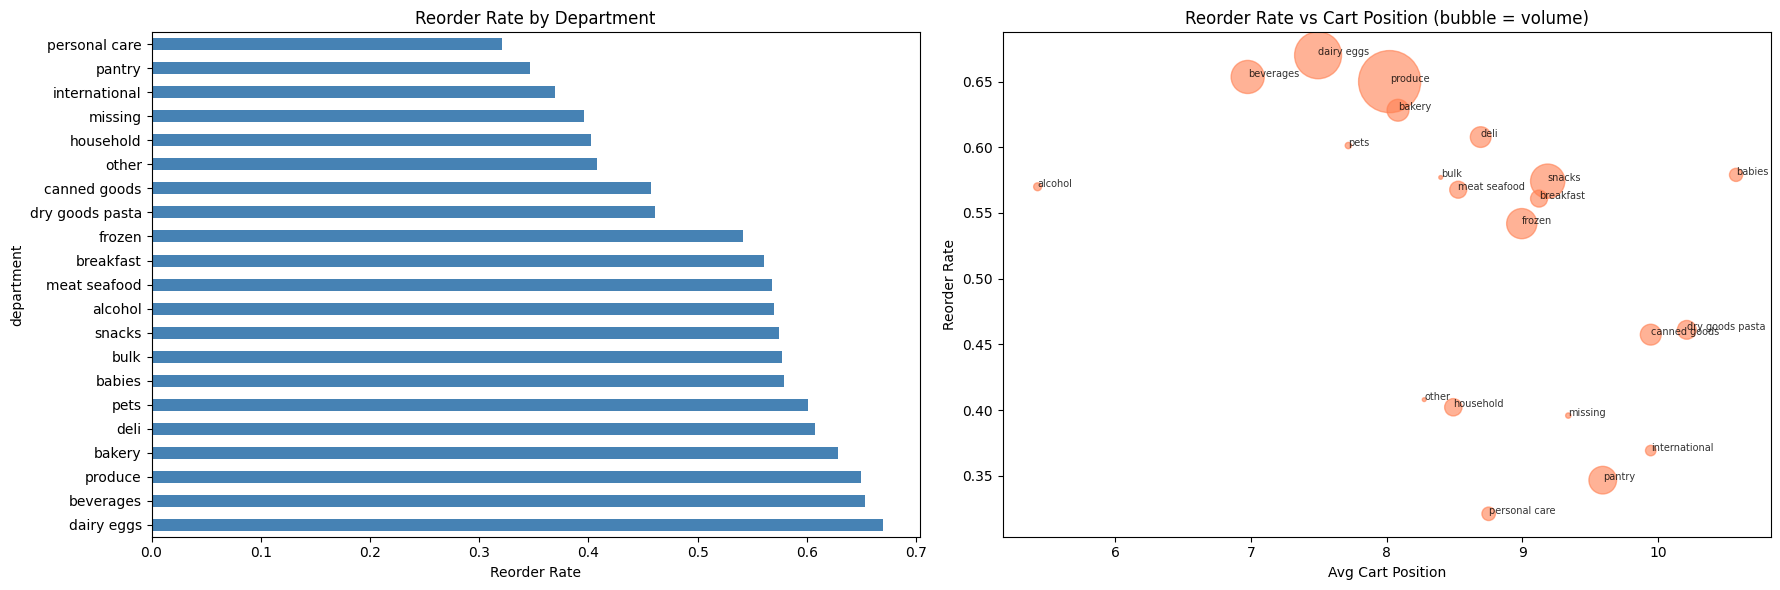

In [129]:
# ── Reorder rate by department ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

dept_stats = (insta_df_clean.groupby("department")
              .agg(reorder_rate=("reordered","mean"),
                   avg_cart_position=("add_to_cart_order","mean"),
                   order_count=("order_id","count"))
              .sort_values("reorder_rate", ascending=False))

dept_stats["reorder_rate"].plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Reorder Rate by Department")
axes[0].set_xlabel("Reorder Rate")

# ── Bubble: reorder rate vs cart position vs volume ───────────────────
axes[1].scatter(
    dept_stats["avg_cart_position"],
    dept_stats["reorder_rate"],
    s=dept_stats["order_count"] / dept_stats["order_count"].max() * 2000,
    alpha=0.6, color="coral"
)
for dept, row in dept_stats.iterrows():
    axes[1].annotate(dept, (row["avg_cart_position"], row["reorder_rate"]),
                     fontsize=7, alpha=0.8)
axes[1].set_xlabel("Avg Cart Position")
axes[1].set_ylabel("Reorder Rate")
axes[1].set_title("Reorder Rate vs Cart Position (bubble = volume)")

plt.tight_layout()
plt.show()

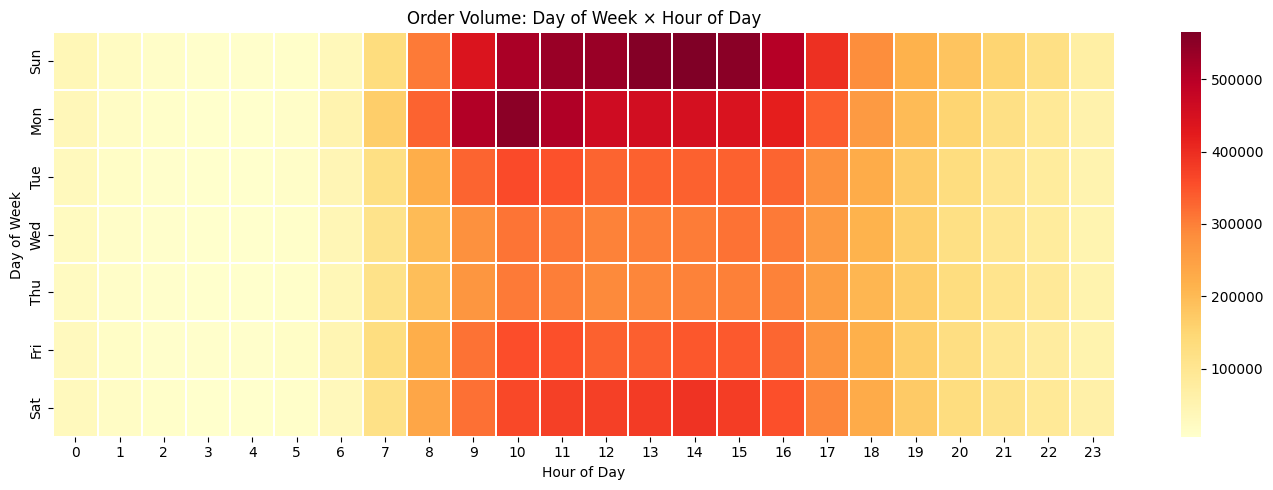

In [130]:
# ── Order timing heatmap: day of week × hour ──────────────────────────
pivot3 = (insta_df_clean.groupby(["order_dow", "order_hour_of_day"])
          .size()
          .unstack(fill_value=0))

pivot3.index = ["Sun","Mon","Tue","Wed","Thu","Fri","Sat"]

plt.figure(figsize=(14, 5))
sns.heatmap(pivot3, cmap="YlOrRd", linewidths=0.3)
plt.title("Order Volume: Day of Week × Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.tight_layout()
plt.show()

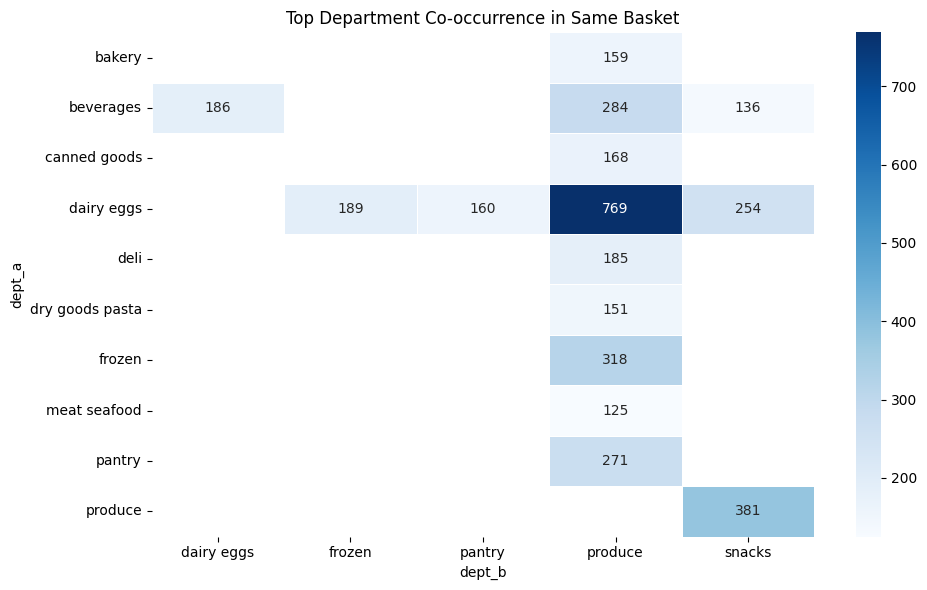

In [131]:
# ── Top cross-department combos per order ─────────────────────────────
from itertools import combinations
from collections import Counter

# Sample for performance
sample_orders = insta_df_clean.sample(min(200000, len(insta_df_clean)), random_state=42)

dept_pairs = Counter()
for order_id, grp in sample_orders.groupby("order_id")["department"]:
    depts = list(set(grp.tolist()))
    for pair in combinations(sorted(depts), 2):
        dept_pairs[pair] += 1

top_pairs = pd.DataFrame(dept_pairs.most_common(15),
                         columns=["Department Pair", "Co-occurrence Count"])
top_pairs["dept_a"] = top_pairs["Department Pair"].apply(lambda x: x[0])
top_pairs["dept_b"] = top_pairs["Department Pair"].apply(lambda x: x[1])

# Plot as heatmap
pair_pivot = top_pairs.pivot(index="dept_a", columns="dept_b", values="Co-occurrence Count")
plt.figure(figsize=(10, 6))
sns.heatmap(pair_pivot, cmap="Blues", annot=True, fmt=".0f", linewidths=0.5)
plt.title("Top Department Co-occurrence in Same Basket")
plt.tight_layout()
plt.show()

### 2D — Cross-Dataset: Linking Sentiment to Sales Performance

C:\Users\peace\AppData\Local\Temp\ipykernel_15424\3437326393.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ecom_agg = (ecom_df_clean.groupby("Category")


     ecom_category  avg_sentiment  avg_rating  avg_profit   avg_sales
0        Furniture       0.739677    4.360720    4.399987  313.975611
1  Office Supplies       0.770656    4.437801   19.848462  122.925662
2       Technology       0.654760    4.213442   81.224770  435.466043


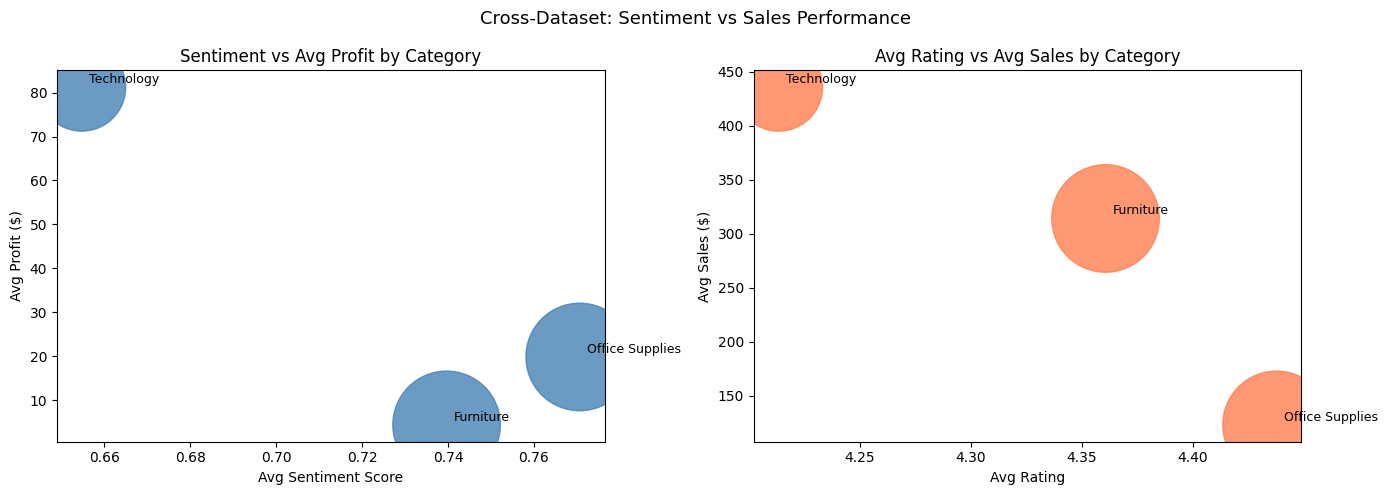

In [135]:
# ── Cross-Dataset: Linking Sentiment to Sales Performance ─────────────
category_map = {
    "Electronics":                 "Technology",
    "Cell_Phones_and_Accessories": "Technology",
    "Office_Products":             "Office Supplies",
    "Arts_Crafts_and_Sewing":      "Office Supplies",
    "Toys_and_Games":              "Office Supplies",
    "Home_and_Kitchen":            "Furniture",
    "Tools_and_Home_Improvement":  "Furniture",
    "Clothing_Shoes_and_Jewelry":  "Furniture",
}

amazon_review_df_clean["ecom_category"] = (
    amazon_review_df_clean["category_name"].astype(str).map(category_map)
)

sentiment_map = {"negative": -1, "neutral": 0, "positive": 1}
amazon_review_df_clean["sentiment_score"] = (
    amazon_review_df_clean["sentiment"].astype(str).map(sentiment_map).astype(float)
)
amazon_review_df_clean["ecom_category"] = amazon_review_df_clean["ecom_category"].astype(str)

review_agg = (amazon_review_df_clean
              .dropna(subset=["ecom_category"])
              .query("ecom_category != 'nan'")
              .groupby("ecom_category")
              .agg(avg_sentiment=("sentiment_score", "mean"),
                   avg_rating=("rating", "mean"),
                   review_count=("rating", "count"))
              .reset_index())

ecom_agg = (ecom_df_clean.groupby("Category")
            .agg(avg_profit=("Profit", "mean"),
                 avg_sales=("Sales", "mean"),
                 avg_discount=("Discount", "mean"))
            .reset_index()
            .rename(columns={"Category": "ecom_category"}))

cross_df = review_agg.merge(ecom_agg, on="ecom_category")

print(cross_df[["ecom_category","avg_sentiment","avg_rating","avg_profit","avg_sales"]])

# ── Plot ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Cross-Dataset: Sentiment vs Sales Performance", fontsize=13)

axes[0].scatter(cross_df["avg_sentiment"], cross_df["avg_profit"],
                s=cross_df["review_count"] / 50, color="steelblue", alpha=0.8)
for _, row in cross_df.iterrows():
    axes[0].annotate(row["ecom_category"],
                     (row["avg_sentiment"], row["avg_profit"]),
                     fontsize=9, textcoords="offset points", xytext=(5, 3))
axes[0].set_xlabel("Avg Sentiment Score")
axes[0].set_ylabel("Avg Profit ($)")
axes[0].set_title("Sentiment vs Avg Profit by Category")

axes[1].scatter(cross_df["avg_rating"], cross_df["avg_sales"],
                s=cross_df["review_count"] / 50, color="coral", alpha=0.8)
for _, row in cross_df.iterrows():
    axes[1].annotate(row["ecom_category"],
                     (row["avg_rating"], row["avg_sales"]),
                     fontsize=9, textcoords="offset points", xytext=(5, 3))
axes[1].set_xlabel("Avg Rating")
axes[1].set_ylabel("Avg Sales ($)")
axes[1].set_title("Avg Rating vs Avg Sales by Category")

plt.tight_layout()
plt.show()

### Exploratory Data Analysis: What Did You Learn from Random Forest?

In [136]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, r2_score, classification_report
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### RF 1 — Ecom: Predict Profit Category (High/Low)

=== ECOM RANDOM FOREST ===
Accuracy: 0.8914
              precision    recall  f1-score   support

           0       0.88      0.88      0.88       300
           1       0.90      0.90      0.90       363

    accuracy                           0.89       663
   macro avg       0.89      0.89      0.89       663
weighted avg       0.89      0.89      0.89       663



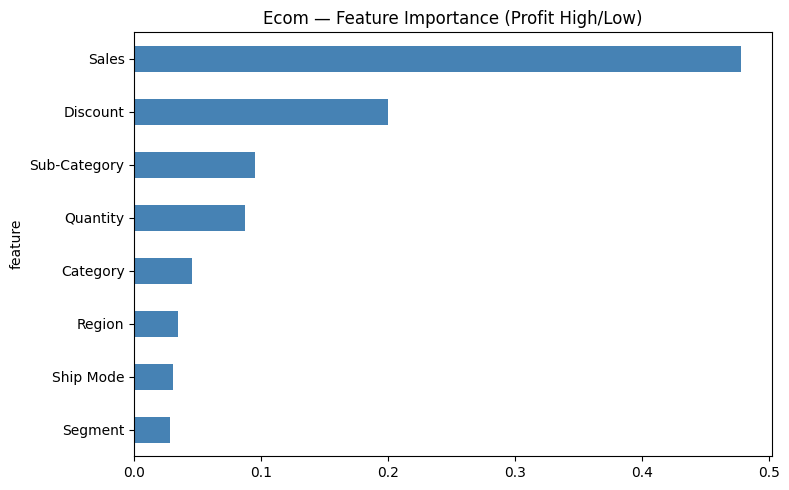

In [137]:
# ── Prep ──────────────────────────────────────────────────────────────
ecom_rf = ecom_df_clean.copy()

# Target: profit above/below median
profit_median = ecom_rf["Profit"].median()
ecom_rf["profit_label"] = (ecom_rf["Profit"] > profit_median).astype(int)

# Encode categoricals
le = LabelEncoder()
for col in ["Ship Mode", "Segment", "Region", "Category", "Sub-Category"]:
    ecom_rf[col] = le.fit_transform(ecom_rf[col].astype(str))

features = ["Sales", "Quantity", "Discount", "Ship Mode", 
            "Segment", "Region", "Category", "Sub-Category"]
X = ecom_rf[features]
y = ecom_rf["profit_label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ── Model ─────────────────────────────────────────────────────────────
rf_ecom = RandomForestClassifier(n_estimators=100, random_state=42)
rf_ecom.fit(X_train, y_train)
y_pred = rf_ecom.predict(X_test)

print("=== ECOM RANDOM FOREST ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

# ── Feature importance ────────────────────────────────────────────────
ecom_importance = pd.DataFrame({
    "feature": features,
    "importance": rf_ecom.feature_importances_
}).sort_values("importance", ascending=True)

ecom_importance.plot(kind="barh", x="feature", y="importance",
                     figsize=(8, 5), color="steelblue", legend=False,
                     title="Ecom — Feature Importance (Profit High/Low)")
plt.tight_layout()
plt.show()

### RF 2 — Amazon: Predict Sentiment (Positive/Negative)

=== AMAZON RANDOM FOREST (leakage fixed) ===
Accuracy: 0.6996
              precision    recall  f1-score   support

           0       0.17      0.40      0.24     72322
           1       0.90      0.74      0.81    534987

    accuracy                           0.70    607309
   macro avg       0.54      0.57      0.53    607309
weighted avg       0.81      0.70      0.74    607309



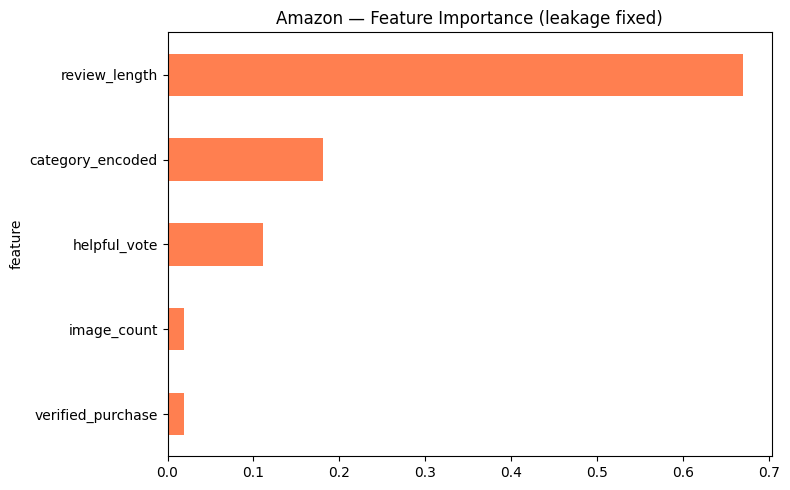

In [141]:
# ── Remove rating — it directly encodes the target ────────────────────
amazon_rf = amazon_review_df_clean.copy()

# Binary target: positive vs negative (drop neutral)
amazon_rf = amazon_rf[amazon_rf["sentiment"].astype(str) != "neutral"]
amazon_rf["sentiment_binary"] = (amazon_rf["sentiment"].astype(str) == "positive").astype(int)

# Encode category
le = LabelEncoder()
amazon_rf["category_encoded"] = le.fit_transform(amazon_rf["category_name"].astype(str))
amazon_rf["verified_purchase"] = amazon_rf["verified_purchase"].astype(int)

# No rating in features
features_amz = ["helpful_vote", "review_length", 
                 "image_count", "verified_purchase", "category_encoded"]

X = amazon_rf[features_amz].fillna(0)
y = amazon_rf["sentiment_binary"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ── Model ─────────────────────────────────────────────────────────────
rf_amazon = RandomForestClassifier(n_estimators=100, random_state=42,
                                    class_weight="balanced")
rf_amazon.fit(X_train, y_train)
y_pred = rf_amazon.predict(X_test)

print("=== AMAZON RANDOM FOREST (leakage fixed) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

# ── Feature importance ────────────────────────────────────────────────
amz_importance = pd.DataFrame({
    "feature": features_amz,
    "importance": rf_amazon.feature_importances_
}).sort_values("importance", ascending=True)

amz_importance.plot(kind="barh", x="feature", y="importance",
                    figsize=(8, 5), color="coral", legend=False,
                    title="Amazon — Feature Importance (leakage fixed)")
plt.tight_layout()
plt.show()

### RF 3 — Instacart: Predict Reorder

=== INSTACART RANDOM FOREST ===
Accuracy: 0.6400
              precision    recall  f1-score   support

           0       0.57      0.48      0.52     16417
           1       0.68      0.75      0.71     23583

    accuracy                           0.64     40000
   macro avg       0.62      0.62      0.62     40000
weighted avg       0.63      0.64      0.63     40000



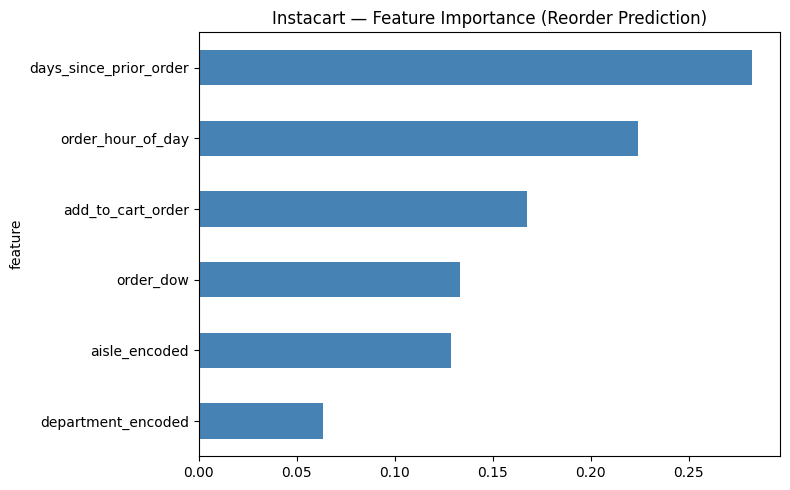

In [139]:
# ── Prep ──────────────────────────────────────────────────────────────
insta_rf = insta_df_clean.sample(200000, random_state=42)  # sample for performance

insta_rf["department_encoded"] = le.fit_transform(insta_rf["department"].astype(str))
insta_rf["aisle_encoded"]      = le.fit_transform(insta_rf["aisle"].astype(str))

features_insta = ["order_dow", "order_hour_of_day", "days_since_prior_order",
                   "add_to_cart_order", "department_encoded", "aisle_encoded"]

X = insta_rf[features_insta].fillna(0)
y = insta_rf["reordered"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ── Model ─────────────────────────────────────────────────────────────
rf_insta = RandomForestClassifier(n_estimators=100, random_state=42,
                                   class_weight="balanced")
rf_insta.fit(X_train, y_train)
y_pred = rf_insta.predict(X_test)

print("=== INSTACART RANDOM FOREST ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

# ── Feature importance ────────────────────────────────────────────────
insta_importance = pd.DataFrame({
    "feature": features_insta,
    "importance": rf_insta.feature_importances_
}).sort_values("importance", ascending=True)

insta_importance.plot(kind="barh", x="feature", y="importance",
                      figsize=(8, 5), color="steelblue", legend=False,
                      title="Instacart — Feature Importance (Reorder Prediction)")
plt.tight_layout()
plt.show()